Determine retrievability of TLogic compliant patterns from synthetic TKGs using TLogic.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy

from collections import defaultdict
from itertools import combinations, combinations_with_replacement, product, permutations

import os
import random
import re

# Utilities

## Handle TLogic mined rules

In [4]:
def extract_triple(s):
    m = re.match(r'^\s*([^\(]+?)\s*\((X\d),\s*(X\d),\s*T\d+\)\s*$', s)
    if not m:
        raise ValueError(f"Could not parse triple: {s}")
    rel, h, t = m.groups()
    rel = re.sub(r'^[,\s]+', '', rel.strip())
    return (h, rel, t)

In [5]:
def normalize_relation(triple):
    # Normalize TLogic's inverse relations by flipping entity order and uninverting relation
    h, r, t = triple
    if r.startswith('_'):
        return (t, r[1:], h)
    return (h, r, t)

In [6]:
def load_mined_rules(file_path):
    """
    Parse TLogic mined rules file (confidence, count, support, 'Head <- body, body, ...').
    Crucial fix: in the body, skip the delimiter ', ' before each triple so it doesn't leak
    into the relation token.
    """
    rules = []
    triple_pattern = re.compile(r'(?:^|,\s*)(.+?)\((X\d),\s*(X\d),\s*T\d+\)')

    with open(file_path, 'r') as f:
        for line in f:
            if '<-' not in line:
                continue
            parts = line.strip().split(maxsplit=3)
            if len(parts) != 4:
                continue
            conf, count, support, rule_str = parts
            try:
                head_str, body_str = rule_str.split(' <- ')
                head = extract_triple(head_str)

                body_matches = triple_pattern.findall(body_str)
                body = []
                for rel, h, t in body_matches:
                    rel = re.sub(r'^[,\s]+', '', rel.strip())
                    body.append((h, rel, t))

                rules.append({
                    'confidence': float(conf),
                    'count': int(count),
                    'support': int(support),
                    'head': head,
                    'body': body,
                    'n_hops': len(body)
                })
            except Exception as e:
                print(f"Skipping rule due to parse error: {e}\n{line}")

    return rules

## Handle synthetic TKG patterns

In [7]:
def load_ground_truth_patterns(file_path):
    gt_patterns = []
    triple_pattern = re.compile(r'\((e\d),\s*(\d+),\s*(e\d),\s*t\d+(?:=.*?)?\)')

    with open(file_path, 'r') as f:
        for line in f:
            if '->' not in line:
                continue
            try:
                rule_part, n_hops, rule_id = line.strip().split('\t')
                body_str, head_str = rule_part.split(' -> ')
                body_matches = triple_pattern.findall(body_str)
                head_match = triple_pattern.findall(head_str)

                if not body_matches or not head_match:
                    continue

                body = [(h, r, t) for h, r, t in body_matches]
                head = head_match[0]
                pattern = canonicalize_pattern(body, head)

                gt_patterns.append({
                    'id': int(rule_id),
                    'n_hops': int(n_hops),
                    'canonical_pattern': pattern,
                    'raw_line': line.strip(),
                    'match_found': False,
                    'matched_rule': None
                })
            except Exception as e:
                print(f"Skipping GT pattern due to parse error: {e}\n{line}")

    return gt_patterns

In [8]:
def load_triples(file_path):
    triples = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) != 4:
                continue
            h, r, t, ts = parts
            triples.append((h, r, t, ts))
    return triples

In [9]:
def extract_instantiated_patterns(triples):
    """Build a lookup of relation triples indexed by time for efficient pattern matching."""
    rel_by_time = defaultdict(list)
    for h, r, t, ts in triples:
        rel_by_time[int(ts)].append((h, r, t))
    return rel_by_time

In [10]:
def count_gt_pattern_instances(gt_patterns, triple_files):
    all_triples = []
    for path in triple_files:
        all_triples += load_triples(path)

    rel_by_time = extract_instantiated_patterns(all_triples)

    # Placeholder counts, real logic involves replaying patterns over time
    for gt in gt_patterns:
        gt['gt_count'] = -1  # placeholder
        gt['gt_support'] = -1  # placeholder

    return gt_patterns

In [11]:
def compute_gt_counts_from_labels(gt_patterns, triple_files):
    from ast import literal_eval

    # Fast lookup of GT pattern IDs
    gt_pattern_ids = set(p['id'] for p in gt_patterns)
    consequence_tracker = defaultdict(set)

    # Updated regex to match both antecedent and consequence labels, but only process '_c_' ones
    pattern_label_re = re.compile(r"(\d+)_([ac]\d?)_((?:e\d=\d+\|?)+)")

    for file_path in triple_files:
        with open(file_path, 'r') as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) < 6:
                    continue  # Malformed line

                h, r, t, ts, _, label_str = parts

                try:
                    pattern_labels = literal_eval(label_str)
                    for label in pattern_labels:
                        match = pattern_label_re.match(label)
                        if not match:
                            continue

                        pattern_id = int(match.group(1))
                        role = match.group(2)
                        bindings_str = match.group(3)

                        # Only count consequences
                        if not role.startswith('c'):
                            continue
                        if pattern_id not in gt_pattern_ids:
                            continue

                        bindings = dict(pair.split('=') for pair in bindings_str.split('|'))
                        key = tuple(sorted(bindings.items())) + (ts,)

                        consequence_tracker[pattern_id].add(key)

                except Exception as e:
                    print(f"Warning: failed to parse label: {label_str}\n{e}")
                    continue

    # Assign counts to GT pattern objects
    for gt in gt_patterns:
        pid = gt['id']
        gt['gt_count'] = len(consequence_tracker.get(pid, set()))
        gt['gt_support'] = None  # Not computed yet

    return gt_patterns

## Analysis/comparison utilities

In [12]:
def canonicalize_pattern(body, head):
    pattern = [normalize_relation(t) for t in body + [head]]
    ent_map = {}
    ent_counter = 1
    canonical = []
    for h, r, t in pattern:
        for e in (h, t):
            if e not in ent_map:
                ent_map[e] = f"e{ent_counter}"
                ent_counter += 1
        canonical.append((ent_map[h], r, ent_map[t]))
    return canonical

In [13]:
def patterns_match(p1, p2):
    # Preserve temporal pattern ordering
    if len(p1) != len(p2):
        return False
    return all(a == b for a, b in zip(p1, p2))

In [14]:
def match_mined_to_gt(gt_patterns, mined_rules):
    for gt in gt_patterns:
        for rule in mined_rules:
            canon_mined = canonicalize_pattern(rule['body'], rule['head'])
            if patterns_match(gt['canonical_pattern'], canon_mined):
                gt['match_found'] = True
                gt['matched_rule'] = rule
                break  # Stop at first match, should be impossible to get multiple matches
    return gt_patterns

In [15]:
def print_retrievability_report(gt_patterns, verbose: bool = False):
    total = len(gt_patterns)
    matched = sum(1 for p in gt_patterns if p['match_found'])
    if verbose:
        print(f"Retrieved {matched}/{total} patterns ({matched/total:.1%})\n")

    for p in gt_patterns:
        if verbose:
            print(f"Pattern ID {p['id']}: {'Found' if p['match_found'] else 'Not found'}")
        if p['match_found']:
            r = p['matched_rule']
            if verbose:
                print(f"\tConf: {r['confidence']}, Count: {r['count']}, Support: {r['support']}")

In [16]:
def run_retrievability_eval(mined_rules_path, gt_patterns_path, verbose: bool = False):
    if verbose: print("Loading mined rules...")
    mined_rules = load_mined_rules(mined_rules_path)

    if verbose: print("Loading ground-truth patterns...")
    gt_patterns = load_ground_truth_patterns(gt_patterns_path)

    if verbose: print("Matching...")
    gt_patterns = match_mined_to_gt(gt_patterns, mined_rules)

    if verbose: print("Results:")
    print_retrievability_report(gt_patterns, verbose)

    return mined_rules, gt_patterns

In [17]:
def canonical_to_key(canon_pattern):
    """Turn a canonical pattern [(e?, r, e?), ...] into a stable readable key."""
    if not canon_pattern:
        return ""
    body = canon_pattern[:-1]
    head = canon_pattern[-1]
    body_str = " & ".join([f"{h}-{r}-{t}" for (h, r, t) in body])
    head_str = f"{head[0]}-{head[1]}-{head[2]}"
    return f"{body_str} -> {head_str}"

In [18]:
def mined_rules_to_canonical_df(mined_rules):
    """Canonicalize mined rules and aggregate duplicates (same canonical_key & n_hops)."""
    rows = []
    for r in mined_rules:
        canon = canonicalize_pattern(r['body'], r['head'])
        key = canonical_to_key(canon)
        rows.append({
            'canonical_key': key,
            'n_hops': r['n_hops'],
            'confidence': r['confidence'],
            'count': r['count'],
            'support': r['support']
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # Aggregate: take max confidence (strongest rule), sum counts/support
    df_agg = (df.groupby(['canonical_key', 'n_hops'], as_index=False)
                .agg(confidence=('confidence', 'max'),
                     count=('count', 'sum'),
                     support=('support', 'sum')))
    return df_agg

In [19]:
def gt_patterns_to_canonical_df(gt_patterns):
    """Flatten GT patterns to a dataframe keyed by canonical_key."""
    rows = []
    for p in gt_patterns:
        key = canonical_to_key(p['canonical_pattern'])
        rows.append({
            'pattern_id': p['id'],
            'n_hops': p['n_hops'],
            'canonical_key': key,
            'gt_count': p.get('gt_count', None)  # may be filled later
        })
    return pd.DataFrame(rows)

In [20]:
def attach_gt_counts(gt_patterns, dataset_root, dataset_name):
    triple_files = [
        os.path.join(dataset_root, dataset_name, f)
        for f in ['train.txt', 'valid.txt', 'test.txt']
    ]
    gt_patterns = compute_gt_counts_from_labels(gt_patterns, triple_files)
    return gt_patterns

In [21]:
# def split_canonical_key(key: str):
#     """
#     'e1-3-e2 & e1-2-e3 -> e2-5-e3' -> (body_list, head_triple)
#     where each triple is a 3-tuple of strings ('e1','3','e2')
#     """
#     if '->' not in key:
#         return [], None
#     body_str, head_str = key.split('->')
#     body_str = body_str.strip()
#     head_str = head_str.strip()
#     body = []
#     if body_str:
#         for part in [s.strip() for s in body_str.split('&')]:
#             if not part:
#                 continue
#             h, r, t = [x.strip() for x in part.split('-')]
#             body.append((h, r, t))
#     h, r, t = [x.strip() for x in head_str.split('-')]
#     head = (h, r, t)
#     return body, head

# def is_subsequence(shorter, longer):
#     """Return True if 'shorter' list is a subsequence (not necessarily contiguous) of 'longer'."""
#     if len(shorter) > len(longer):
#         return False
#     it = iter(longer)
#     return all(any(a == b for b in it) for a in shorter)

In [22]:
# # TODO Do we want to require heads to be the same for it to be a subsequence?
# def classify_fp_against_gt(fp_key: str, gt_keys_for_same_dataset: list) -> str:
#     """
#     Heuristic FP taxonomy:
#       - 'subpattern' if FP has same head as some GT and FP body is a subsequence of that GT body
#       - 'superpattern' if FP has same head as some GT and GT body is a subsequence of FP body
#       - 'composition' if FP head matches some GT head and FP body can be covered by the union
#         of subsequences from multiple GTs with that head (very light-weight check)
#       - 'other' otherwise
#     """
#     fp_body, fp_head = split_canonical_key(fp_key)
#     if fp_head is None:
#         return 'other'

#     # group GTs by head
#     gt_by_head = defaultdict(list)
#     for gk in gt_keys_for_same_dataset:
#         gb, gh = split_canonical_key(gk)
#         gt_by_head[gh].append(gb)

#     # same head?
#     if fp_head not in gt_by_head:
#         return 'other'

#     gt_bodies = gt_by_head[fp_head]

#     # subpattern?
#     for gb in gt_bodies:
#         if is_subsequence(fp_body, gb):
#             return 'subpattern'

#     # superpattern?
#     for gb in gt_bodies:
#         if is_subsequence(gb, fp_body):
#             return 'superpattern'

#     # composition? (greedy cover: do FP triples each appear in at least one GT body with same head)
#     # (ignores ordering across different GTs; good enough as a first pass)
#     fp_triples = set(fp_body)
#     union_gt_triples = set()
#     for gb in gt_bodies:
#         union_gt_triples.update(gb)
#     if fp_triples.issubset(union_gt_triples):
#         return 'composition'

#     return 'other'

In [23]:
def split_canonical_key(key: str):
    """
    key: 'e1-r-e2 & e3-r-e4 -> e5-r-e6'
    returns: (body_list, head_triple) where each triple is a tuple (h, r, t)
    """
    if '->' not in key:
        return [], None
    body_str, head_str = [x.strip() for x in key.split('->', 1)]
    def parse_triple(s):
        h, r, t = [p.strip() for p in s.split('-', 2)]
        return (h, r, t)
    body = []
    if body_str:
        for chunk in [c.strip() for c in body_str.split('&') if c.strip()]:
            body.append(parse_triple(chunk))
    head = parse_triple(head_str)
    return body, head

def is_subsequence(small, big):
    """
    Ordered (not-necessarily contiguous) subsequence check:
    each element of `small` must appear in `big` in the same order.
    """
    if not small:
        return True
    it = iter(big)
    return all(any(b == a for b in it) for a in small)

def is_unordered_subset(small, big):
    """
    Unordered subset check by multiset (counts preserved).
    """
    from collections import Counter
    return not (Counter(small) - Counter(big))

In [24]:
def classify_fp_against_gt(fp_key: str, gt_keys_for_same_dataset: list) -> set:
    """
    Multi-label taxonomy for a false-positive (FP) canonical pattern.

    We emit labels from:
      - 'same-head-subpattern-ordered'
      - 'same-head-subpattern-unordered'
      - 'same-head-superpattern-ordered'
      - 'same-head-superpattern-unordered'
      - 'same-head-composition'
      - 'diff-head-subpattern-ordered'
      - 'diff-head-subpattern-unordered'
      - 'diff-head-superpattern-ordered'
      - 'diff-head-superpattern-unordered'
      - 'diff-head-composition'

    Notes
    -----
    • "subpattern" means FP is (ordered / unordered) subset of a GT.
    • "superpattern" means FP is (ordered / unordered) superset of a GT.
    • "composition":
        same-head   → every FP *body* triple appears in the union of GT bodies with that head
        diff-head   → every FP triple (body+head) appears in the union of all GT triples (body+head)
    • If no category matches, returns {'other'}.
    """
    labels = set()

    fp_body, fp_head = split_canonical_key(fp_key)
    fp_full = fp_body + ([fp_head] if fp_head else [])

    # Parse all GT keys once
    gt_parsed = []
    gt_by_head = defaultdict(list)
    for gk in gt_keys_for_same_dataset:
        gb, gh = split_canonical_key(gk)
        gt_parsed.append((gb, gh, gb + [gh]))
        if gh is not None:
            gt_by_head[gh].append(gb)

    # -------- same-head regime --------
    if fp_head in gt_by_head:
        gt_bodies_same_head = gt_by_head[fp_head]

        # subpattern/superpattern (ordered & unordered) comparing *bodies*, head fixed
        for gb in gt_bodies_same_head:
            if is_subsequence(fp_body, gb):
                labels.add('same-head-subpattern-ordered')
            if is_unordered_subset(fp_body, gb):
                labels.add('same-head-subpattern-unordered')

            if is_subsequence(gb, fp_body):
                labels.add('same-head-superpattern-ordered')
            if is_unordered_subset(gb, fp_body):
                labels.add('same-head-superpattern-unordered')

        # composition (same-head): every FP body triple must appear in the union of GT bodies with that head
        union_gt_triples = set()
        for gb in gt_bodies_same_head:
            union_gt_triples.update(gb)
        if set(fp_body).issubset(union_gt_triples):
            labels.add('same-head-composition')

    # -------- different-head regime --------
    # Treat head+body uniformly, as requested (compare concatenated sequences)
    gt_full_all = [full for _, _, full in gt_parsed]

    # subpattern/superpattern (ordered & unordered) on full sequences (body+head)
    for full in gt_full_all:
        if is_subsequence(fp_full, full):
            labels.add('diff-head-subpattern-ordered')
        if is_unordered_subset(fp_full, full):
            labels.add('diff-head-subpattern-unordered')

        if is_subsequence(full, fp_full):
            labels.add('diff-head-superpattern-ordered')
        if is_unordered_subset(full, fp_full):
            labels.add('diff-head-superpattern-unordered')

    # composition (diff-head): every FP triple (body+head) in union of *all* GT triples (body+head)
    union_all_gt_triples = set()
    for full in gt_full_all:
        union_all_gt_triples.update(full)
    if set(fp_full).issubset(union_all_gt_triples):
        labels.add('diff-head-composition')

    # If nothing matched, mark as 'other'
    if not labels:
        labels.add('other')

    return labels

## Naming Helpers

In [25]:
def base_from_run(name: str) -> str:
    """Strip trailing __run_<i> to get the base config name."""
    m = re.match(r'^(.*)__run_\d+$', name)
    return m.group(1) if m else name

def is_synt_like(name: str) -> bool:
    return name.startswith('synt_tlogic_like')

def is_synt_like_med(name: str) -> bool:
    return name.startswith('synt_tlogic_like_med')

def is_data_shorter(name: str) -> bool:
    return name.startswith('data_tlogic_like_shorter_pattern_tmax__')

def is_data_shorter_med(name: str) -> bool:
    return name.startswith('data_tlogic_like_shorter_pattern_tmax_med__')

def strip_run_suffix(name: str) -> str:
    """Remove trailing run suffix no matter if it's _run_<i> or __run_<i>."""
    return re.sub(r'(?:__run_\d+|_run_\d+)$', '', name)

def base_from_run(name: str) -> str:
    """Alias kept for backward-compat; use strip_run_suffix."""
    return strip_run_suffix(name)

def parse_nhop_grid(name: str):
    """
    Extract (N, n, p) from both styles, e.g.:
      data_tlogic_like_3hop25_n_force2_p_force04__run_1
      data_tlogic_like_3hop25_n_force2_p_force04_run_1
      data_tlogic_like_3hop25_n_force2_p_force04
    Returns (N, n, p) or None.
    """
    base = strip_run_suffix(name)
    m = re.match(r'^data_tlogic_like_(\d)hop\d+_n_force(\d+)_p_force(\d+)$', base)
    if not m:
        return None
    N = int(m.group(1)); n = int(m.group(2)); p = int(m.group(3))
    return (N, n, p)

# Run

TODO See: https://chatgpt.com/s/t_68de13d893948191a836ac71b426e26d

In [26]:
# Which n to scan (from learn_apply_evaluate_all_hyperparams_symlink.sh)
NUM_WALKS_LIST = [50, 100, 200, 400, 800, 1600]
RUNNR = 0
SEED = 0
RULE_NAME = f"{RUNNR}_r[1,2,3]_n{{n}}_exp_s{SEED}_rules.txt"

mined_rules_root = '/nas/ckgfs/users/eboxer/TKG-Forecasting-Evaluation/TLogic/output/'
gt_patterns_root = '/nas/ckgfs/users/eboxer/TKG-Forecasting-Evaluation/TLogic/data/'

FILTER_REGEX='^(data_tlogic_like_[1-3]hop.*|data_tlogic_like_shorter.*|data_tlogic_like|data_tlogic_like_med)$'
tkg_names = [
    tkg_name for tkg_name in os.listdir(mined_rules_root)
    if re.match(FILTER_REGEX, tkg_name)
]

all_mined_rules, all_gt_patterns = [], []

for tkg_name in tkg_names:
    mined_rules, gt_patterns = run_retrievability_eval(
        os.path.join(mined_rules_root, tkg_name, '0_r[1,2,3]_n200_exp_s0_rules.txt'),
        os.path.join(gt_patterns_root, tkg_name, 'pattern2id.txt')
    )
    all_mined_rules.append(mined_rules)
    all_gt_patterns.append(gt_patterns)
len(all_gt_patterns)

60

In [27]:
# all_rows = []
# all_fp_rows = []

# for tkg_name, mined_rules, gt_patterns in zip(
#     tkg_names, all_mined_rules, all_gt_patterns
# ):
#     # Attach ground truth counts from edgelists
#     gt_patterns = attach_gt_counts(gt_patterns, gt_patterns_root, tkg_name)

#     # Canonical tables
#     df_gt = gt_patterns_to_canonical_df(gt_patterns)
#     df_mined = mined_rules_to_canonical_df(mined_rules)

#     # Mark retrieval by canonical_key
#     df_gt['dataset'] = tkg_name
#     if df_mined.empty:
#         # No mined rules → mark as not retrieved
#         df_gt['retrieved'] = False
#         df_gt['mined_confidence'] = np.nan
#         df_gt['mined_count'] = np.nan
#         df_gt['mined_support'] = np.nan
#         all_rows.append(df_gt)
#         continue

#     # Join ground truth to mined on canonical_key (+ sanity by n_hops)
#     df_join = (
#         df_gt.merge(
#             df_mined, on=['canonical_key', 'n_hops'], how='left', suffixes=('', '_mined')
#         ).rename(columns={
#             'confidence': 'mined_confidence',
#             'count': 'mined_count',
#             'support': 'mined_support'}
#         )
#     )
#     df_join['dataset'] = tkg_name
#     df_join['retrieved'] = ~df_join['mined_confidence'].isna()
#     all_rows.append(df_join)

#     # False positives: mined canonical patterns not present in GT for this dataset
#     gt_keys = set(df_gt['canonical_key'].unique())
#     df_fp = df_mined[~df_mined['canonical_key'].isin(gt_keys)].copy()
#     df_fp['dataset'] = tkg_name
#     all_fp_rows.append(df_fp)

# # Concatenate across datasets
# df_all = pd.concat(all_rows, ignore_index=True)
# df_fp_all = pd.concat(all_fp_rows, ignore_index=True) if len(all_fp_rows) else pd.DataFrame()

# # Nice column order
# cols = ['dataset', 'pattern_id', 'n_hops', 'canonical_key',
#         'retrieved', 'gt_count', 'mined_confidence', 'mined_count', 'mined_support']
# df_all = df_all.reindex(columns=[c for c in cols if c in df_all.columns])

# print("df_all shape:", df_all.shape)
# print("df_fp_all shape:", df_fp_all.shape)

In [28]:
rows_all = []
rows_fp  = []

for ds in tkg_names:
    gt_path = os.path.join(gt_patterns_root, ds, 'pattern2id.txt')
    for n in NUM_WALKS_LIST:
        rules_path = os.path.join(mined_rules_root, ds, RULE_NAME.format(n=n))
        if not os.path.exists(rules_path):
            # quietly skip missing n
            continue

        mined_rules, gt_patterns = run_retrievability_eval(rules_path, gt_path)
        # attach counts from labels
        gt_patterns = attach_gt_counts(gt_patterns, gt_patterns_root, ds)

        df_gt = gt_patterns_to_canonical_df(gt_patterns)
        df_m  = mined_rules_to_canonical_df(mined_rules)

        df_gt['dataset'] = ds
        df_gt['num_walks'] = n

        if df_m.empty:
            df_gt['retrieved'] = False
            df_gt['mined_confidence'] = np.nan
            df_gt['mined_count'] = np.nan
            df_gt['mined_support'] = np.nan
            rows_all.append(df_gt)
            continue

        df_join = (df_gt.merge(df_m, on=['canonical_key','n_hops'], how='left',
                               suffixes=('', '_mined'))
                        .rename(columns={'confidence':'mined_confidence',
                                         'count':'mined_count',
                                         'support':'mined_support'}))
        df_join['retrieved'] = ~df_join['mined_confidence'].isna()
        rows_all.append(df_join)

        # false positives for this (ds, n)
        gt_keys = set(df_gt['canonical_key'].unique())
        df_fp = df_m[~df_m['canonical_key'].isin(gt_keys)].copy()
        df_fp['dataset'] = ds
        df_fp['num_walks'] = n
        rows_fp.append(df_fp)

df_all = pd.concat(rows_all, ignore_index=True) if rows_all else pd.DataFrame()
df_fp_all = pd.concat(rows_fp, ignore_index=True) if rows_fp else pd.DataFrame()

print("df_all shape:", df_all.shape)
print("df_fp_all shape:", df_fp_all.shape)

df_all shape: (12348, 10)
df_fp_all shape: (2660098, 7)


In [ ]:
# # Combine with previous results
# prev_out_dir = "./retrievability_outputs"
# prev_gt_vs_mined = os.path.join(prev_out_dir, "retrievability_gt_vs_mined_v0.csv")
# prev_fp = os.path.join(prev_out_dir, "retrievability_false_positives_v0.csv")

# dfs = []
# if 'df_all' in globals() and isinstance(df_all, pd.DataFrame):
#     dfs.append(df_all.copy())

# if os.path.exists(prev_gt_vs_mined):
#     dfs.append(pd.read_csv(prev_gt_vs_mined))

# df_all_combined = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# fp_dfs = []
# if 'df_fp_all' in globals() and isinstance(df_fp_all, pd.DataFrame) and not df_fp_all.empty:
#     fp_dfs.append(df_fp_all.copy())
# if os.path.exists(prev_fp):
#     fp_dfs.append(pd.read_csv(prev_fp))

# df_fp_combined = pd.concat(fp_dfs, ignore_index=True) if fp_dfs else pd.DataFrame()

# print("Combined GT-vs-mined rows:", len(df_all_combined))
# print("Combined false-positive rows:", len(df_fp_combined))

Combined GT-vs-mined rows: 12618
Combined false-positive rows: 2669800


In [64]:
def prf1_by_group(df_all, df_fp, keys=('dataset','n_hops','num_walks')):
    # GT side: TP & FN
    gt_counts = (df_all.groupby(list(keys))
                    .agg(TP=('retrieved', 'sum'),
                         GT=('retrieved', 'size'))
                    .reset_index())
    gt_counts['FN'] = gt_counts['GT'] - gt_counts['TP']

    # FP side: count mined-not-in-GT per group
    if df_fp.empty:
        fp_counts = gt_counts[list(keys)].copy()
        fp_counts['FP'] = 0
    else:
        fp_counts = (df_fp.groupby(list(keys))
                         .size()
                         .reset_index(name='FP'))

    out = (gt_counts.merge(fp_counts, on=list(keys), how='left')
                    .fillna({'FP':0}))
    # Precision/Recall/F1
    out['precision'] = out['TP'] / (out['TP'] + out['FP']).replace(0, np.nan)
    out['recall']    = out['TP'] / (out['TP'] + out['FN']).replace(0, np.nan)
    out['f1']        = 2*out['TP'] / (2*out['TP'] + out['FP'] + out['FN']).replace(0, np.nan)
    out['accuracy']  = (out['TP']) / (out['TP'] + out['FP'] + out['FN'])

    return out

prf_df = prf1_by_group(df_all, df_fp_all, keys=('dataset','n_hops','num_walks'))

In [65]:
def strip_run_suffix(name: str) -> str:
    return re.sub(r'(?:__run_\d+|_run_\d+)$', '', name)

def is_synt_like(name):      return name.startswith('synt_tlogic_like')
def is_synt_like_med(name):  return name.startswith('synt_tlogic_like_med')
def is_shorter(name):        return name.startswith('data_tlogic_like_shorter_pattern_tmax__')
def is_shorter_med(name):    return name.startswith('data_tlogic_like_shorter_pattern_tmax_med__')

prf_df['base_config'] = prf_df['dataset'].apply(strip_run_suffix)
prf_df['family'] = np.select(
    [
        prf_df['dataset'].apply(is_synt_like_med),
        prf_df['dataset'].apply(is_synt_like),
        prf_df['dataset'].apply(is_shorter_med),
        prf_df['dataset'].apply(is_shorter),
    ],
    ['synt_med','synt','shorter_med','shorter'],
    default='other'
)

In [66]:
prf_df[:3]

,dataset,n_hops,num_walks,TP,GT,FN,FP,precision,recall,f1,accuracy,base_config,family
0,data_tlogic_like_1hop50_n_force1_p_force02__run_0,1,50,46,46,0,87,0.345865,1.0,0.513966,0.345865,data_tlogic_like_1hop50_n_force1_p_force02,other
1,data_tlogic_like_1hop50_n_force1_p_force02__run_0,1,100,46,46,0,105,0.304636,1.0,0.467005,0.304636,data_tlogic_like_1hop50_n_force1_p_force02,other
2,data_tlogic_like_1hop50_n_force1_p_force02__run_0,1,200,46,46,0,122,0.273810,1.0,0.429907,0.273810,data_tlogic_like_1hop50_n_force1_p_force02,other


/tmp/ipykernel_3112338/1408558806.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])


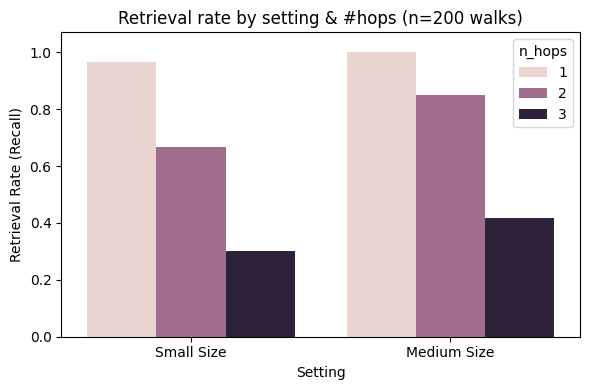

In [67]:
N_TARGET = 200
cmp_recall = (prf_df[prf_df['num_walks']==N_TARGET]
              .groupby(['family','base_config','n_hops'], as_index=False)['recall']
              .mean()
              .rename(columns={'recall':'retrieval_rate'}))

plt.figure(figsize=(6,4))
ax = sns.barplot(data=cmp_recall[cmp_recall['family'].isin(['shorter','shorter_med'])],
                 x='family', y='retrieval_rate', hue='n_hops',
                 hue_order=[1,2,3])
ax.set_ylim(0,1.07)
ax.set_xlabel('Setting'); ax.set_ylabel('Retrieval Rate (Recall)')
ax.set_title(f'Retrieval rate by setting & #hops (n={N_TARGET} walks)')
label_map = {'shorter':'Small Size','shorter_med':'Medium Size'}
ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
plt.tight_layout(); plt.show()

/tmp/ipykernel_3112338/3836268079.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])


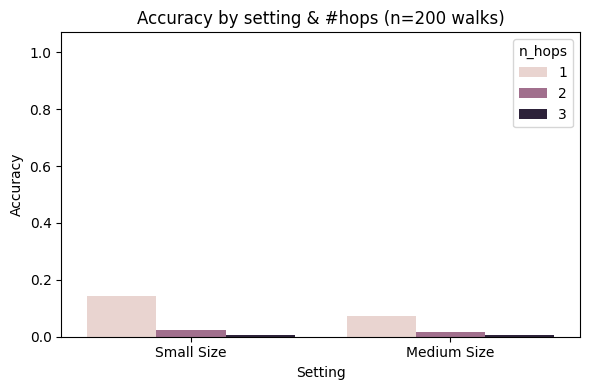

In [68]:
N_TARGET = 200
cmp_recall = (prf_df[prf_df['num_walks']==N_TARGET]
              .groupby(['family','base_config','n_hops'], as_index=False)['accuracy']
              .mean()
              .rename(columns={'accuracy':'accuracy'}))

plt.figure(figsize=(6,4))
ax = sns.barplot(data=cmp_recall[cmp_recall['family'].isin(['shorter','shorter_med'])],
                 x='family', y='accuracy', hue='n_hops',
                 hue_order=[1,2,3])
ax.set_ylim(0,1.07)
ax.set_xlabel('Setting'); ax.set_ylabel('Accuracy')
ax.set_title(f'Accuracy by setting & #hops (n={N_TARGET} walks)')
label_map = {'shorter':'Small Size','shorter_med':'Medium Size'}
ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
plt.tight_layout(); plt.show()

/tmp/ipykernel_3112338/41539532.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])


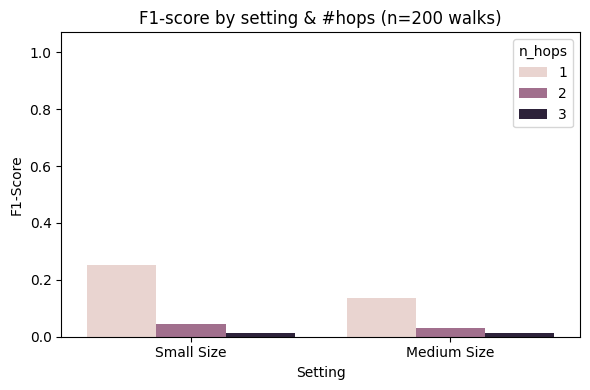

In [70]:
N_TARGET = 200
cmp_recall = (prf_df[prf_df['num_walks']==N_TARGET]
              .groupby(['family','base_config','n_hops'], as_index=False)['f1']
              .mean()
              .rename(columns={'f1':'F1'}))

plt.figure(figsize=(6,4))
ax = sns.barplot(data=cmp_recall[cmp_recall['family'].isin(['shorter','shorter_med'])],
                 x='family', y='F1', hue='n_hops',
                 hue_order=[1,2,3])
ax.set_ylim(0,1.07)
ax.set_xlabel('Setting'); ax.set_ylabel('F1-Score')
ax.set_title(f'F1-score by setting & #hops (n={N_TARGET} walks)')
label_map = {'shorter':'Small Size','shorter_med':'Medium Size'}
ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
plt.tight_layout(); plt.show()

***

/tmp/ipykernel_3112338/92675865.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
/tmp/ipykernel_3112338/92675865.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
/tmp/ipykernel_3112338/92675865.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
/tmp/ipykernel_3112338/92675865.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
/tmp/ipykernel_3112338/92675

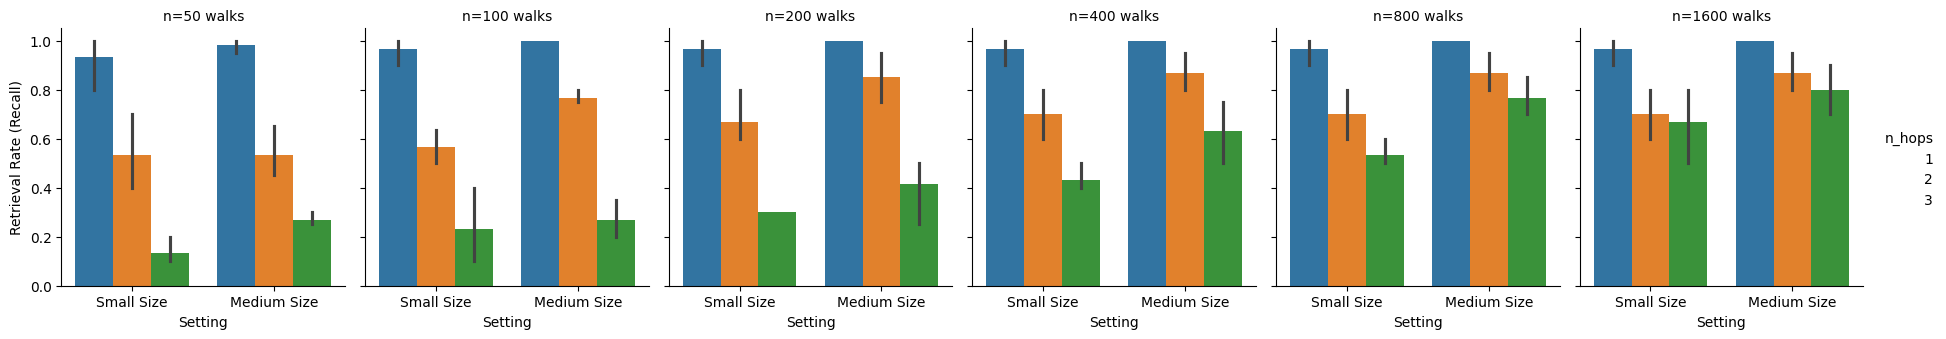

In [56]:
# compare synt vs synt_med, facet by num_walks
df_plot = (prf_df[prf_df['family'].isin(['shorter','shorter_med'])]
           .copy()
           .assign(n_hops=lambda d: pd.Categorical(d['n_hops'], [1,2,3], ordered=True)))

g = sns.catplot(data=df_plot, kind='bar',
                x='family', y='recall', hue='n_hops', col='num_walks',
                hue_order=[1,2,3], col_order=sorted(df_plot['num_walks'].unique()),
                height=3.5, aspect=0.9)
g.set_axis_labels('Setting', 'Retrieval Rate (Recall)')
g.set_titles('n={col_name} walks')
for ax in g.axes.flat:
    ax.set_ylim(0,1.05)
    ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
                        get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
plt.show()

/tmp/ipykernel_3112338/1256628685.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
/tmp/ipykernel_3112338/1256628685.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
/tmp/ipykernel_3112338/1256628685.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
/tmp/ipykernel_3112338/1256628685.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
/tmp/ipykernel_31123

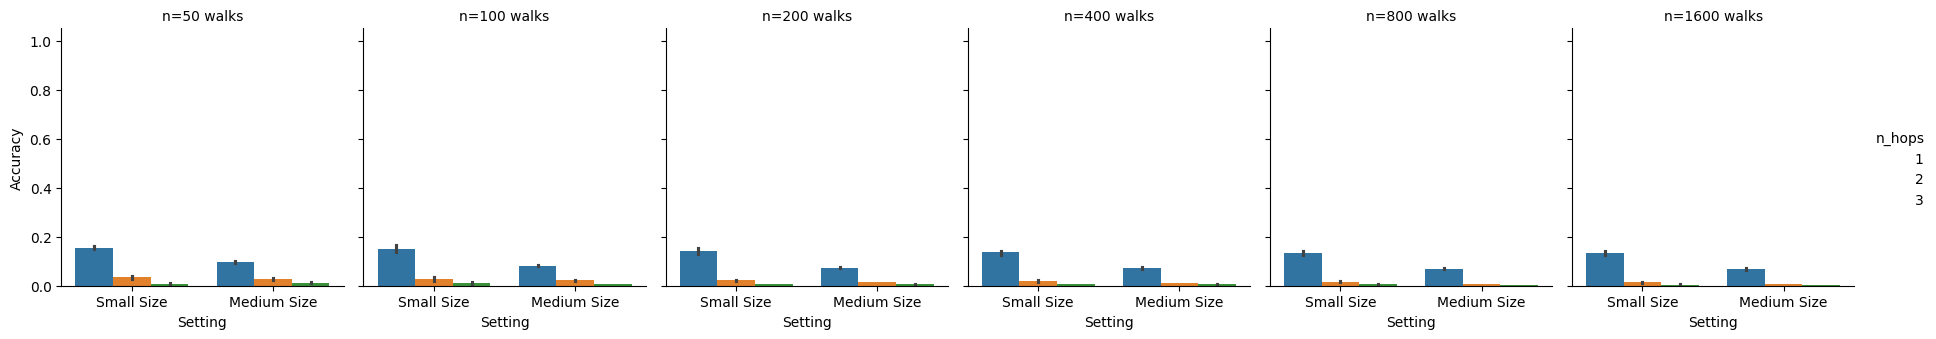

In [71]:
# compare synt vs synt_med, facet by num_walks
df_plot = (prf_df[prf_df['family'].isin(['shorter','shorter_med'])]
           .copy()
           .assign(n_hops=lambda d: pd.Categorical(d['n_hops'], [1,2,3], ordered=True)))

g = sns.catplot(data=df_plot, kind='bar',
                x='family', y='accuracy', hue='n_hops', col='num_walks',
                hue_order=[1,2,3], col_order=sorted(df_plot['num_walks'].unique()),
                height=3.5, aspect=0.9)
g.set_axis_labels('Setting', 'Accuracy')
g.set_titles('n={col_name} walks')
for ax in g.axes.flat:
    ax.set_ylim(0,1.05)
    ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
                        get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
plt.show()

/tmp/ipykernel_3112338/826662854.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
/tmp/ipykernel_3112338/826662854.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
/tmp/ipykernel_3112338/826662854.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
/tmp/ipykernel_3112338/826662854.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
/tmp/ipykernel_3112338/8

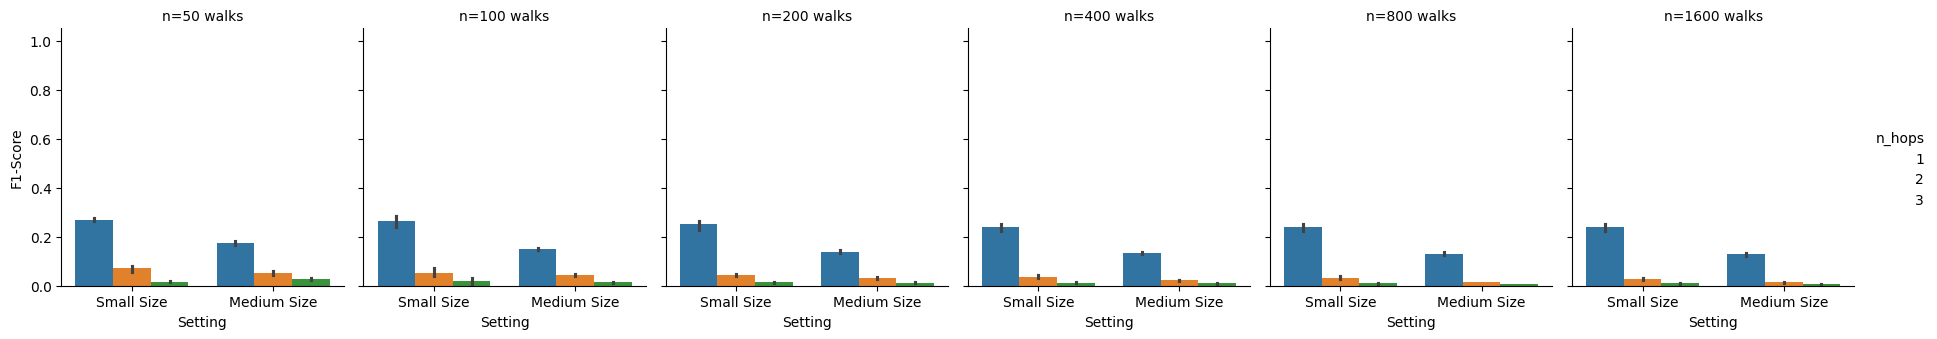

In [72]:
# compare synt vs synt_med, facet by num_walks
df_plot = (prf_df[prf_df['family'].isin(['shorter','shorter_med'])]
           .copy()
           .assign(n_hops=lambda d: pd.Categorical(d['n_hops'], [1,2,3], ordered=True)))

g = sns.catplot(data=df_plot, kind='bar',
                x='family', y='f1', hue='n_hops', col='num_walks',
                hue_order=[1,2,3], col_order=sorted(df_plot['num_walks'].unique()),
                height=3.5, aspect=0.9)
g.set_axis_labels('Setting', 'F1-Score')
g.set_titles('n={col_name} walks')
for ax in g.axes.flat:
    ax.set_ylim(0,1.05)
    ax.set_xticklabels([{'shorter':'Small Size','shorter_med':'Medium Size'}.
                        get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
plt.show()

***

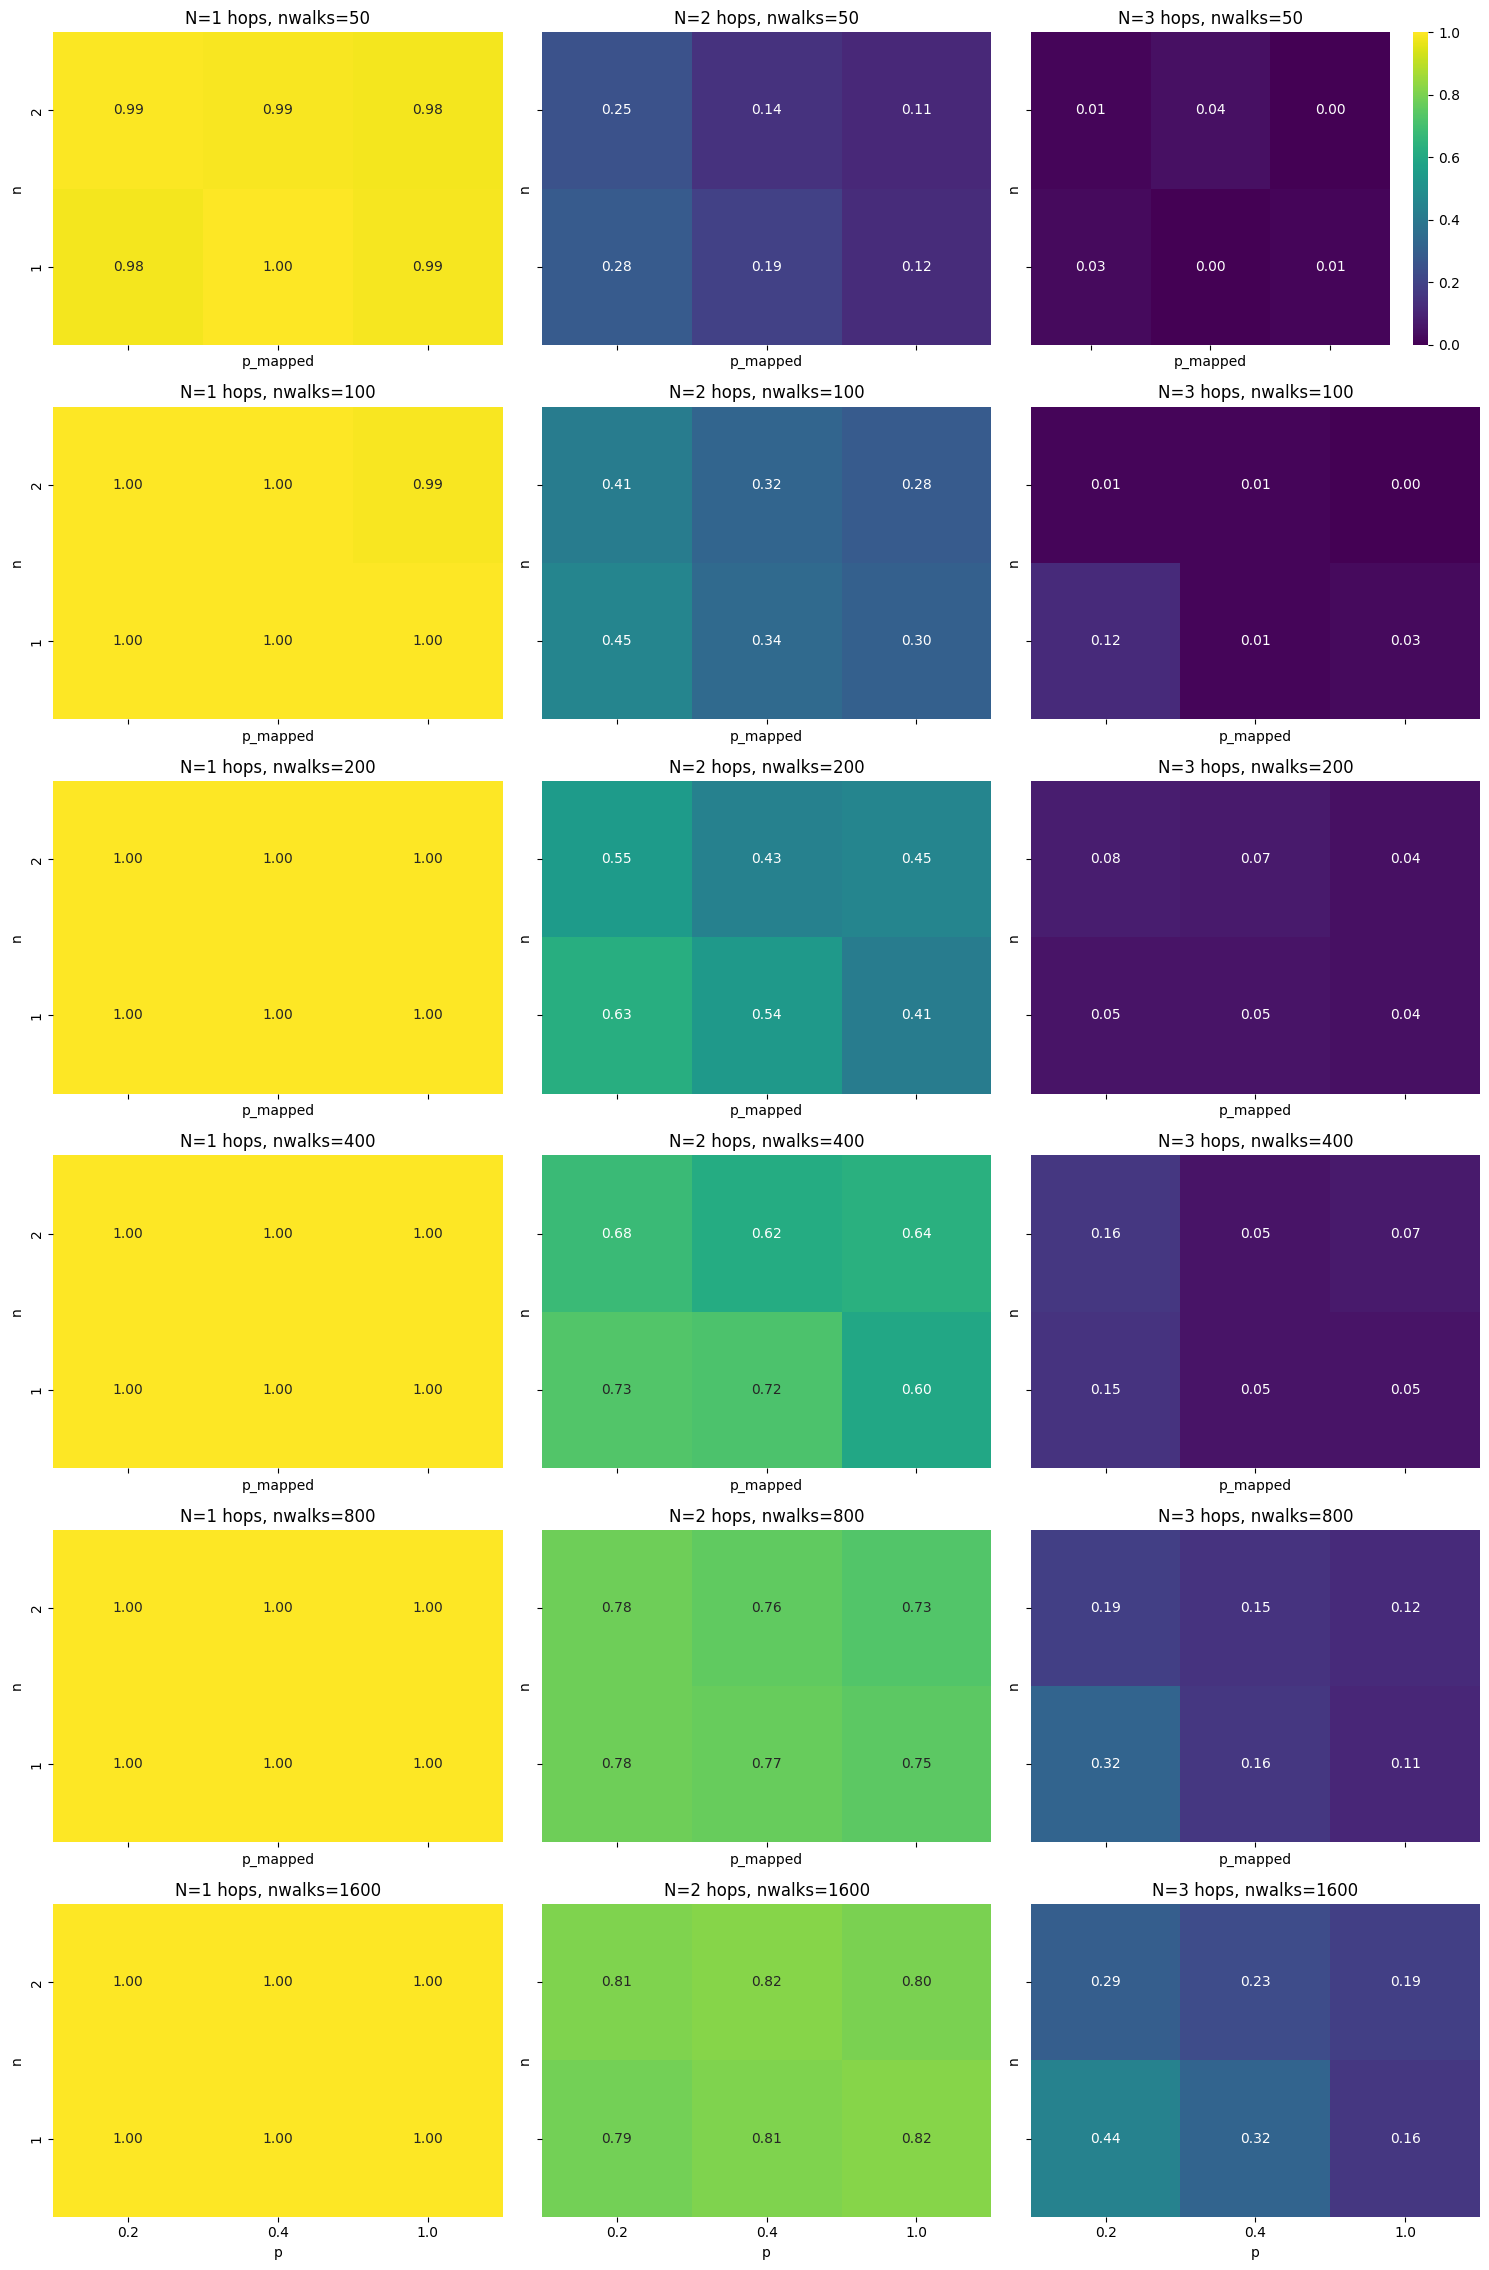

In [59]:
grid_rows = []
agg = prf_df.groupby(['dataset','num_walks'], as_index=False)['recall'].mean()

for ds, nwalk, rate in agg.itertuples(index=False):
    parsed = parse_nhop_grid(ds)
    if parsed is None:
        continue
    N, n, p = parsed
    grid_rows.append({'N': N, 'n': n, 'p': p, 'num_walks': nwalk, 'recall': rate})

gdf = pd.DataFrame(grid_rows)
if not gdf.empty:
    gdf['p_mapped'] = gdf['p'].map({2: 0.2, 4: 0.4, 1: 1.0})

    Ns = sorted(gdf['N'].unique())
    nwalks = sorted(gdf['num_walks'].unique())
    p_order = [0.2, 0.4, 1.0]
    n_order = [2, 1]

    fig, axes = plt.subplots(len(nwalks), len(Ns),
                             figsize=(5*len(Ns), 3.8*len(nwalks)),
                             sharex=True, sharey=True)

    # make `axes` 2D in all cases
    if len(nwalks) == 1 and len(Ns) == 1:
        axes = np.array([[axes]])
    elif len(nwalks) == 1:
        axes = axes[np.newaxis, :]
    elif len(Ns) == 1:
        axes = axes[:, np.newaxis]

    for i, nwalk in enumerate(nwalks):
        for j, N in enumerate(Ns):
            ax = axes[i, j]
            sub = (gdf[(gdf['N'] == N) & (gdf['num_walks'] == nwalk)]
                   # aggregate duplicates across datasets
                   .pivot_table(index='n', columns='p_mapped', values='recall', aggfunc='mean')
                   .reindex(index=n_order)
                   .reindex(columns=p_order))

            sns.heatmap(sub, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='viridis',
                        ax=ax, cbar=(i == 0 and j == len(Ns) - 1))
            ax.set_title(f'N={N} hops, nwalks={nwalk}')
            if i == len(nwalks) - 1:
                ax.set_xlabel('p')
            if j == 0:
                ax.set_ylabel('n')

    plt.tight_layout()
    plt.show()

***

In [60]:
def plot_count_panel(ax, counts_df, category_order, title):
    x_idx = np.arange(len(category_order)); bar_width = 0.22
    for i, hop in enumerate([1,2,3]):
        sub = counts_df[counts_df['n_hops']==hop]
        m = dict(zip(sub['category'], sub['count']))
        c = dict(zip(sub['category'], sub['ci95']))
        y  = np.array([m.get(cat, 0.0) for cat in category_order], dtype=float)
        yc = np.array([c.get(cat, 0.0) for cat in category_order], dtype=float)
        xpos = x_idx + (i - 1)*bar_width
        bars = ax.bar(xpos, y, width=bar_width, color=_HOP_PALETTE[hop], edgecolor='black',
                      yerr=yc, capsize=3, linewidth=0.7, label=f'{hop}')
        for rect, cat in zip(bars, category_order):
            rect.set_hatch(_hatch_for(cat)); rect.set_alpha(1.0 if cat=='TP' else 0.85)
    ax.set_xticks(x_idx); ax.set_xticklabels(category_order, rotation=30, ha='right')
    ax.set_title(title); ax.set_ylabel('Mean count across runs')
    ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.35); ax.set_axisbelow(True)

# Old plots

In [49]:
out_dir = "./retrievability_outputs"
os.makedirs(out_dir, exist_ok=True)

# df_all.to_csv(os.path.join(out_dir, "retrievability_gt_vs_mined.csv"), index=False)
# if not df_fp_all.empty:
#     df_fp_all.to_csv(os.path.join(out_dir, "retrievability_false_positives.csv"), index=False)
# print("Saved CSVs to", out_dir)

In [50]:
# Combine with previous results
prev_out_dir = "./retrievability_outputs"
prev_gt_vs_mined = os.path.join(prev_out_dir, "retrievability_gt_vs_mined_v0.csv")
prev_fp = os.path.join(prev_out_dir, "retrievability_false_positives_v0.csv")

dfs = []
if 'df_all' in globals() and isinstance(df_all, pd.DataFrame):
    dfs.append(df_all.copy())

if os.path.exists(prev_gt_vs_mined):
    dfs.append(pd.read_csv(prev_gt_vs_mined))

df_all_combined = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

fp_dfs = []
if 'df_fp_all' in globals() and isinstance(df_fp_all, pd.DataFrame) and not df_fp_all.empty:
    fp_dfs.append(df_fp_all.copy())
if os.path.exists(prev_fp):
    fp_dfs.append(pd.read_csv(prev_fp))

df_fp_combined = pd.concat(fp_dfs, ignore_index=True) if fp_dfs else pd.DataFrame()

print("Combined GT-vs-mined rows:", len(df_all_combined))
print("Combined false-positive rows:", len(df_fp_combined))

Combined GT-vs-mined rows: 2328
Combined false-positive rows: 245655


# Analysis

In [51]:
# Average retrievability across runs for the same config
if not df_all_combined.empty:
    df_all_combined['base_config'] = df_all_combined['dataset'].apply(strip_run_suffix)

retrieval_by_base = (df_all_combined
                     .groupby('base_config', as_index=False)['retrieved']
                     .mean()
                     .rename(columns={'retrieved': 'mean_retrieval_rate'}))
display(retrieval_by_base.sort_values('base_config'))

retrieval_by_base_hops = (df_all_combined
                          .groupby(['base_config','n_hops'], as_index=False)['retrieved']
                          .mean()
                          .rename(columns={'retrieved': 'mean_retrieval_rate'}))
display(retrieval_by_base_hops.sort_values(['base_config','n_hops']))

,base_config,mean_retrieval_rate
0,data_tlogic_like_1hop50_n_force1_p_force02,1.000000
1,data_tlogic_like_1hop50_n_force1_p_force04,1.000000
2,data_tlogic_like_1hop50_n_force1_p_force1,1.000000
3,data_tlogic_like_1hop50_n_force2_p_force02,1.000000
4,data_tlogic_like_1hop50_n_force2_p_force04,1.000000
5,data_tlogic_like_1hop50_n_force2_p_force1,1.000000
6,data_tlogic_like_2hop33_n_force1_p_force02,0.585859
7,data_tlogic_like_2hop33_n_force1_p_force04,0.484848
8,data_tlogic_like_2hop33_n_force1_p_force1,0.424242
9,data_tlogic_like_2hop33_n_force2_p_force02,0.494949


,base_config,n_hops,mean_retrieval_rate
0,data_tlogic_like_1hop50_n_force1_p_force02,1,1.000000
1,data_tlogic_like_1hop50_n_force1_p_force04,1,1.000000
2,data_tlogic_like_1hop50_n_force1_p_force1,1,1.000000
3,data_tlogic_like_1hop50_n_force2_p_force02,1,1.000000
4,data_tlogic_like_1hop50_n_force2_p_force04,1,1.000000
5,data_tlogic_like_1hop50_n_force2_p_force1,1,1.000000
6,data_tlogic_like_2hop33_n_force1_p_force02,2,0.585859
7,data_tlogic_like_2hop33_n_force1_p_force04,2,0.484848
8,data_tlogic_like_2hop33_n_force1_p_force1,2,0.424242
9,data_tlogic_like_2hop33_n_force2_p_force02,2,0.494949


In [52]:
# Tag families
if not df_all_combined.empty:
    df_all_combined['family'] = np.select(
        [
            df_all_combined['dataset'].apply(is_synt_like_med),
            df_all_combined['dataset'].apply(is_synt_like),
            df_all_combined['dataset'].apply(is_data_shorter_med),
            df_all_combined['dataset'].apply(is_data_shorter),
        ],
        ['synt_med', 'synt', 'shorter_med', 'shorter'],
        default='other'
    )
    df_all_combined['base_config'] = df_all_combined['dataset'].apply(base_from_run)

# Compare retrieval rate by n_hops within each family
cmp = (df_all_combined
       .groupby(['family','base_config','n_hops'])['retrieved']
       .mean()
       .reset_index(name='retrieval_rate'))
display(cmp.sort_values(['family','base_config','n_hops']))

# Focused comparisons:
#  - synt_tlogic_like_med_*  vs  data_tlogic_like_shorter_pattern_tmax_med__*
cmp_med = cmp[cmp['family'].isin(['synt_med','shorter_med'])].copy()
#  - synt_tlogic_like_*      vs  data_tlogic_like_shorter_pattern_tmax__*
cmp_short = cmp[cmp['family'].isin(['synt','shorter'])].copy()

# Plot side-by-side bars per base_config & n_hops
def plot_family_compare(df, title):
    if df.empty:
        print(f"(no rows for {title})")
        return
    plt.figure(figsize=(12,5))
    sns.barplot(data=df, x='base_config', y='retrieval_rate', hue='family')
    plt.ylim(0,1.05)
    plt.xticks(rotation=30, ha='right')
    plt.title(title)
    plt.tight_layout()
    plt.show()

,family,base_config,n_hops,retrieval_rate
0,other,data_tlogic_like_1hop50_n_force1_p_force02,1,1.000000
1,other,data_tlogic_like_1hop50_n_force1_p_force04,1,1.000000
2,other,data_tlogic_like_1hop50_n_force1_p_force1,1,1.000000
3,other,data_tlogic_like_1hop50_n_force2_p_force02,1,1.000000
4,other,data_tlogic_like_1hop50_n_force2_p_force04,1,1.000000
5,other,data_tlogic_like_1hop50_n_force2_p_force1,1,1.000000
6,other,data_tlogic_like_2hop33_n_force1_p_force02,2,0.585859
7,other,data_tlogic_like_2hop33_n_force1_p_force04,2,0.484848
8,other,data_tlogic_like_2hop33_n_force1_p_force1,2,0.424242
9,other,data_tlogic_like_2hop33_n_force2_p_force02,2,0.494949


/tmp/ipykernel_850298/2416812756.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])


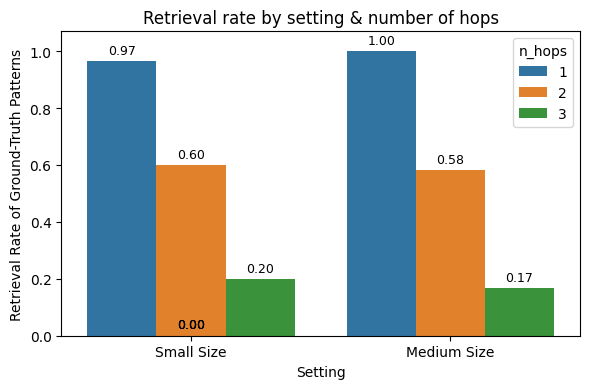

family,synt,synt_med,delta
n_hops,,,
1,0.966667,1.000000,0.033333
2,0.600000,0.583333,-0.016667
3,0.200000,0.166667,-0.033333


In [53]:
# 1) Filter + tidy
df_plot = (cmp[cmp['family'].isin(['synt', 'synt_med'])].copy()
             .assign(n_hops=lambda d: pd.Categorical(d['n_hops'], [1,2,3], ordered=True))
          )

# 2) Grouped bar plot: families on x, bars by n_hops
plt.figure(figsize=(6,4))
ax = sns.barplot(data=df_plot, x='family', y='retrieval_rate', hue='n_hops')
ax.set_title('Retrieval rate by setting & number of hops')
ax.set_ylabel('Retrieval Rate of Ground-Truth Patterns')
ax.set_xlabel('Setting')
ax.set_ylim(0, 1.07)
ax.legend(title='n_hops', loc='upper right')

# optional: value labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}",
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=9, xytext=(0,3), textcoords='offset points')

plt.tight_layout()

label_map = {'synt': 'Small Size', 'synt_med': 'Medium Size'}
ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
plt.draw()

plt.show()

# 3) Tiny comparison table (synt vs synt_med) + deltas per hop
cmp_tbl = (df_plot.pivot(index='n_hops', columns='family', values='retrieval_rate')
                    .reindex([1,2,3])
                    .assign(delta=lambda d: d['synt_med'] - d['synt']))
display(cmp_tbl)

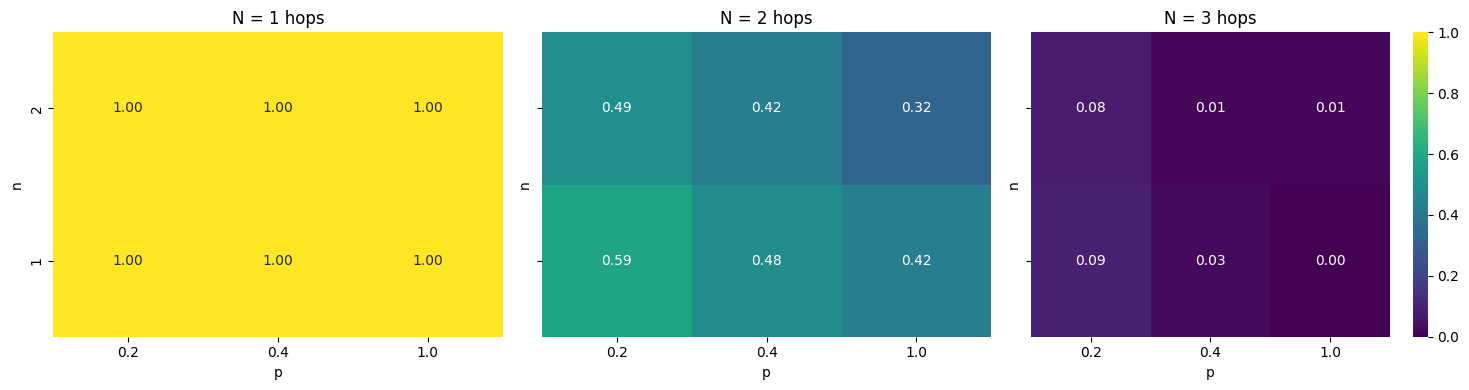

In [54]:
grid_rows = []
if not df_all_combined.empty:
    agg_by_ds = (df_all_combined.groupby('dataset', as_index=False)['retrieved']
                                .mean()
                                .rename(columns={'retrieved': 'retrieval_rate'}))
    for ds, rate in agg_by_ds.itertuples(index=False):
        parsed = parse_nhop_grid(ds)   # now accepts both _run_ and __run_ or none
        if parsed is None:
            continue
        N, n, p = parsed
        grid_rows.append({'N': N, 'n': n, 'p': p, 'dataset': ds, 'retrieval_rate': rate})

df_grid = pd.DataFrame(grid_rows)

if df_grid.empty:
    print("(No nhop grid datasets found)")
else:
    # average across runs with same (N,n,p)
    df_grid_avg = (df_grid
                   .groupby(['N','n','p'], as_index=False)
                   .agg(retrieval_rate=('retrieval_rate','mean')))
    # pivot per N
    Ns = sorted(df_grid_avg['N'].unique())
    fig, axes = plt.subplots(1, len(Ns), figsize=(5*len(Ns), 4), sharex=False, sharey=True)

    if len(Ns) == 1:
        axes = [axes]

    for ax, N in zip(axes, Ns):
        sub = df_grid_avg[df_grid_avg['N'] == N].copy()
        # rows = n, cols = p
        sub['p_mapped'] = sub['p'].map({2: 0.2, 4: 0.4, 1: 1.0})
        pivot = (sub.pivot(index='n', columns='p_mapped', values='retrieval_rate')
                .reindex(index=[2, 1])
                .reindex(columns=[0.2, 0.4, 1.0]))
        sns.heatmap(pivot, annot=True, fmt=".2f", vmin=0, vmax=1, cmap='viridis', ax=ax, cbar=(ax==axes[-1]))
        ax.set_title(f"N = {N} hops")
        ax.set_xlabel("p")
        ax.set_ylabel("n")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_850298/810056867.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pv = (df2.pivot_table(index=['family_group','n_hops'],


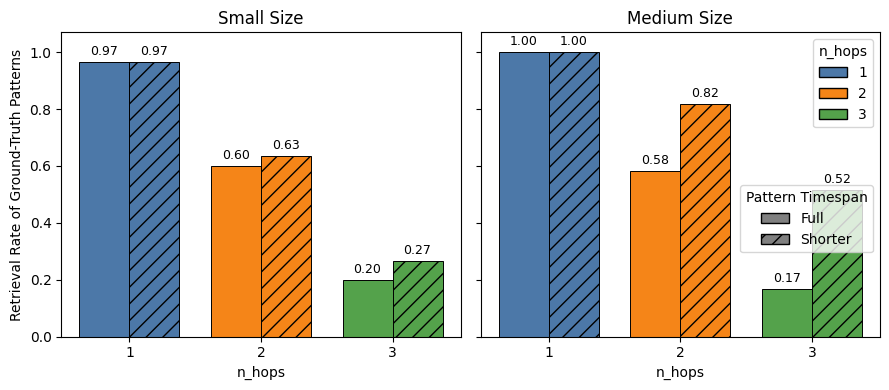

In [57]:
# 1) Prepare data from `cmp`
map_family = {'synt': 'Small Size', 'synt_med': 'Medium Size',
              'shorter': 'Small Size', 'shorter_med': 'Medium Size'}
map_variant = {'synt': 'Full', 'synt_med': 'Full',
               'shorter': 'Shorter', 'shorter_med': 'Shorter'}

df2 = (cmp[cmp['family'].isin(['synt','synt_med','shorter','shorter_med'])].copy()
         .assign(family_group=lambda d: d['family'].map(map_family),
                 variant=lambda d: d['family'].map(map_variant),
                 n_hops=lambda d: pd.Categorical(d['n_hops'], [1,2,3], ordered=True)))

# Pivot: (setting, n_hops) -> Full/Shorter rates
pv = (df2.pivot_table(index=['family_group','n_hops'],
                      columns='variant', values='retrieval_rate', aggfunc='mean')
          .reindex(index=pd.MultiIndex.from_product(
              [sorted(df2['family_group'].unique()), [1,2,3]],
              names=['family_group','n_hops']
          )))

settings = [s for s in ['Small Size','Medium Size'] if s in df2['family_group'].unique()]
hops = [1,2,3]

# 2) Plot
fig, axes = plt.subplots(1, len(settings), figsize=(9,4), sharey=True)
if len(settings) == 1:
    axes = [axes]

# fixed colors per hop
hop_colors = {1: '#4C78A8', 2: '#F58518', 3: '#54A24B'}  # blue, orange, green
bar_w = 0.38
hatch = '//'

for ax, setting in zip(axes, settings):
    xs = np.arange(len(hops), dtype=float)
    # plot each hop as a pair (Full left / Shorter right)
    for i, h in enumerate(hops):
        row = pv.loc[(setting, h)]
        full_val = float(row.get('Full', np.nan)) if 'Full' in row.index else np.nan
        short_val = float(row.get('Shorter', np.nan)) if 'Shorter' in row.index else np.nan

        # Full (left)
        b1 = ax.bar(xs[i] - bar_w/2, full_val,
                    width=bar_w, color=hop_colors[h], edgecolor='black', linewidth=0.7)
        # Shorter (right) – same color, but hatched
        b2 = ax.bar(xs[i] + bar_w/2, short_val,
                    width=bar_w, color=hop_colors[h], edgecolor='black',
                    linewidth=0.7, hatch=hatch)

        # annotate
        for b in (b1, b2):
            if not np.isnan(b.datavalues[0]):  # matplotlib>=3.8; for older, use b.get_height()
                hgt = b.datavalues[0]
            else:
                hgt = b.patches[0].get_height() if hasattr(b, 'patches') and b.patches else np.nan
            rect = b[0] if hasattr(b, '__getitem__') else b
            height = rect.get_height()
            if np.isfinite(height):
                ax.annotate(f"{height:.2f}",
                            (rect.get_x() + rect.get_width()/2, height),
                            ha='center', va='bottom', fontsize=9, xytext=(0,3),
                            textcoords='offset points')

    ax.set_xticks(xs)
    ax.set_xticklabels([str(h) for h in hops])
    ax.set_xlabel('n_hops')
    ax.set_ylim(0, 1.07)
    ax.set_title(setting)

axes[0].set_ylabel('Retrieval Rate of Ground-Truth Patterns')

# 3) Legends — colors for hops + fill/hatch for variant, both on the right subplot
# (a) n_hops legend (color-coded)
hop_handles = [Patch(facecolor=hop_colors[h], edgecolor='black', label=str(h)) for h in hops]
leg1 = axes[-1].legend(handles=hop_handles, title='n_hops',
                       loc='upper right', frameon=True)
axes[-1].add_artist(leg1)

# (b) Variant legend (fill vs hatch)
variant_handles = [
    Patch(facecolor='gray', edgecolor='black', label='Full'),
    Patch(facecolor='gray', edgecolor='black', hatch=hatch, label='Shorter')
]
axes[-1].legend(handles=variant_handles, title='Pattern Timespan',
                loc='upper right', bbox_to_anchor=(1.0, 0.52), frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
# # Build per-dataset GT canonical keys for reference
# gt_keys_by_dataset = defaultdict(set)
# if not df_all_combined.empty:
#     gt_rows = df_all_combined[['dataset','canonical_key']].dropna().drop_duplicates()
#     for ds, key in gt_rows.itertuples(index=False):
#         gt_keys_by_dataset[ds].add(key)

In [93]:
# Build a mapping from dataset → set of GT canonical keys for that dataset
gt_keys_by_dataset = (
    df_all_combined.groupby('dataset')['canonical_key']
          .apply(lambda s: set(s.dropna().tolist()))
          .to_dict()
)

def classify_row(row):
    ds = row['dataset']
    fp_key = row['canonical_key']
    return classify_fp_against_gt(fp_key, list(gt_keys_by_dataset.get(ds, [])))

df_fp_combined['taxonomy_labels'] = df_fp_combined.apply(classify_row, axis=1)

In [61]:
def make_tp_fp_conf_df(df_all, df_fp_all, datasets, fp_col='taxonomy_labels'):
    """
    Returns a tidy dataframe with columns:
      dataset, n_hops, category, confidence
    where category in {'TP', <FP taxonomy labels>}.
    """
    rows = []

    # TRUE POSITIVES (retrieved GT patterns)
    tp = (df_all[df_all['retrieved'] & df_all['dataset'].isin(datasets)]
            .dropna(subset=['mined_confidence']))
    rows.append(tp[['dataset', 'n_hops']].assign(
        category='TP',
        confidence=tp['mined_confidence'].astype(float)
    ))

    # FALSE POSITIVES (explode taxonomy labels so FPs can belong to multiple categories)
    if fp_col in df_fp_all.columns:
        fpf = df_fp_all[df_fp_all['dataset'].isin(datasets)].copy()
        fpf = fpf.explode(fp_col)
        fpf = fpf.dropna(subset=[fp_col, 'confidence'])
        fpf = fpf.rename(columns={fp_col: 'category'})
        rows.append(fpf[['dataset','n_hops','category','confidence']].assign(
            confidence=lambda d: d['confidence'].astype(float)
        ))

    out = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(
        columns=['dataset','n_hops','category','confidence']
    )
    # nice ordering for hops
    out['n_hops'] = pd.Categorical(out['n_hops'], [1,2,3], ordered=True)
    return out

In [99]:
def summarize_conf(df):
    if df.empty:
        return df
    grp = (df.groupby(['dataset', 'n_hops', 'category'], observed=True)
             .agg(mean_conf=('confidence', 'mean'),
                  sem=('confidence', 'sem'),
                  n=('confidence', 'size'))
             .reset_index())
    grp['ci95'] = 1.96 * grp['sem'].fillna(0.0)
    return grp

In [102]:
def plot_confidence_bars(
    summ,
    datasets,
    category_order,
    figsize=(8, 4),
    title="TP vs FP confidence by category",
):
    """
    summ columns expected: dataset, n_hops, category, mean_conf, ci95
    """
    if summ.empty:
        print("(nothing to plot)")
        return

    # only keep requested datasets
    summ_f = summ[summ["dataset"].isin(datasets)].copy()

    # consistent hop palette (same colors you've been using)
    hop_levels = [1, 2, 3]
    hop_palette = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}  # blue, orange, green

    # hatching: TP solid; same-head vs diff-head use different hatches
    def hatch_for(cat):
        if cat == "TP":
            return ""          # filled (no hatch)
        return "//" if cat.startswith("same-head") else "xx"

    x_idx = np.arange(len(category_order))
    bar_width = 0.22

    fig, ax = plt.subplots(figsize=figsize)

    for i, hop in enumerate(hop_levels):
        sub = summ_f[summ_f["n_hops"] == hop]

        # Build y and ci arrays aligned to the full category_order
        y = []
        y_ci = []
        for cat in category_order:
            rows = sub[sub["category"] == cat]
            if not rows.empty:
                y.append(rows["mean_conf"].mean())
                y_ci.append(rows["ci95"].mean())
            else:
                y.append(np.nan)      # no data for this category at this hop
                y_ci.append(0.0)

        y = np.array(y, dtype=float)
        y_ci = np.array(y_ci, dtype=float)

        # x positions for this hop inside each category group
        xpos = x_idx + (i - (len(hop_levels) - 1) / 2) * bar_width

        # Use 0 height for NaNs so shapes always match
        bars = ax.bar(
            xpos,
            np.nan_to_num(y, nan=0.0),
            width=bar_width,
            color=hop_palette.get(hop, "#888"),
            edgecolor="black",
            yerr=y_ci,
            capsize=3,
            linewidth=0.7,
            label=f"{hop}",
        )

        # Apply hatching per category
        for rect, cat in zip(bars, category_order):
            rect.set_hatch(hatch_for(cat))
            # Make FP bars slightly translucent so the hatch reads well
            rect.set_alpha(1.0 if cat == "TP" else 0.85)

    ax.set_xticks(x_idx)
    ax.set_xticklabels(category_order, rotation=30, ha="right")
    ax.set_ylabel("Mean confidence")
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.legend(title="n_hops", loc="upper right")
    fig.tight_layout()
    plt.show()

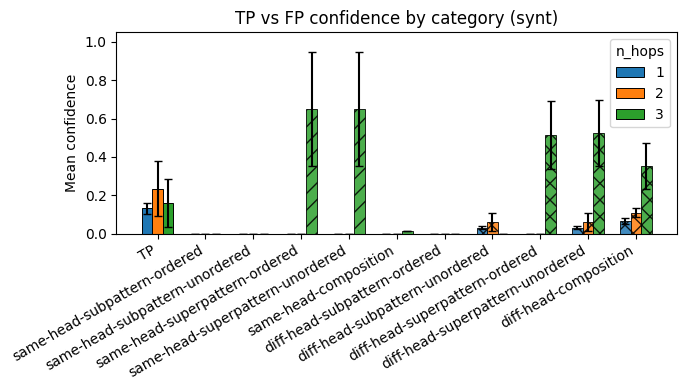

In [103]:
# choose datasets to compare
datasets_to_plot = [
    d for d in df_all_combined['dataset'].unique()
    if 'synt_tlogic_like' in d and not 'med' in d
]
# Build combined table
conf_df = make_tp_fp_conf_df(df_all_combined, df_fp_combined, datasets_to_plot)
summ = summarize_conf(conf_df)

# Friendly category order (TP first, then a few common FP buckets)
category_order = [
    'TP',
    'same-head-subpattern-ordered',
    'same-head-subpattern-unordered',
    'same-head-superpattern-ordered',
    'same-head-superpattern-unordered',
    'same-head-composition',
    'diff-head-subpattern-ordered',
    'diff-head-subpattern-unordered',
    'diff-head-superpattern-ordered',
    'diff-head-superpattern-unordered',
    'diff-head-composition',
]

plot_confidence_bars(
    summ,
    datasets=datasets_to_plot,
    category_order=category_order,
    figsize=(7,4),
    title='TP vs FP confidence by category (synt)'
)

***

In [140]:
# ---------- helpers to aggregate & plot as 2x2 panels ----------

# consistent hop palette & hatching
_HOP_LEVELS = [1, 2, 3]
_HOP_PALETTE = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}  # blue, orange, green

def _hatch_for(cat: str) -> str:
    if cat == "TP":
        return ""  # solid for TP
    return "//" if cat.startswith("same-head") else "xx"

def _align_to_categories(series_like, categories):
    """Return numpy array aligned to full category list; fill missing with 0/NaN depending on dtype."""
    out = []
    for cat in categories:
        val = series_like.get(cat, np.nan)
        out.append(val)
    return np.array(out, dtype=float)

def plot_conf_panel(ax, summ_avg, category_order, title):
    """
    ax: matplotlib axes to draw on
    summ_avg: dataframe grouped by ['n_hops','category'] with mean_conf, ci95
    """
    x_idx = np.arange(len(category_order))
    bar_width = 0.22

    for i, hop in enumerate(_HOP_LEVELS):
        sub = summ_avg[summ_avg['n_hops'] == hop]

        # maps 'category' -> value
        mean_map = dict(zip(sub['category'], sub['mean_conf']))
        ci_map   = dict(zip(sub['category'], sub['ci95']))

        y    = _align_to_categories(mean_map, category_order)
        y_ci = _align_to_categories(ci_map, category_order)
        y[np.isnan(y)] = 0.0   # zero height where missing
        y_ci[np.isnan(y_ci)] = 0.0

        xpos = x_idx + (i - (len(_HOP_LEVELS) - 1) / 2) * bar_width

        bars = ax.bar(
            xpos, y, width=bar_width,
            color=_HOP_PALETTE.get(hop, "#888"),
            edgecolor="black",
            yerr=y_ci, capsize=3, linewidth=0.7,
            label=f"{hop}"
        )
        for rect, cat in zip(bars, category_order):
            rect.set_hatch(_hatch_for(cat))
            rect.set_alpha(1.0 if cat == "TP" else 0.85)

    ax.set_xticks(x_idx)
    ax.set_xticklabels(category_order, rotation=30, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Mean confidence")
    ax.set_title(title)

def plot_count_panel(ax, counts_df, category_order, title):
    """
    ax: matplotlib axes to draw on
    counts_df: dataframe grouped by ['n_hops','category'] with 'count'
    """
    x_idx = np.arange(len(category_order))
    bar_width = 0.22

    max_y = 0
    for i, hop in enumerate(_HOP_LEVELS):
        sub = counts_df[counts_df['n_hops'] == hop]

        cnt_map = dict(zip(sub['category'], sub['count']))
        y = _align_to_categories(cnt_map, category_order)
        y[np.isnan(y)] = 0.0

        xpos = x_idx + (i - (len(_HOP_LEVELS) - 1) / 2) * bar_width

        bars = ax.bar(
            xpos, y, width=bar_width,
            color=_HOP_PALETTE.get(hop, "#888"),
            edgecolor="black",
            linewidth=0.7,
            label=f"{hop}"
        )
        for rect, cat in zip(bars, category_order):
            rect.set_hatch(_hatch_for(cat))
            rect.set_alpha(1.0 if cat == "TP" else 0.85)
        max_y = max(max_y, np.nanmax(y))

    ax.set_xticks(x_idx)
    ax.set_xticklabels(category_order, rotation=30, ha="right")
    ax.set_ylim(0, max(1.0, max_y * 1.15))
    ax.set_ylabel("Count")
    ax.set_title(title)


In [141]:
# def build_conf_and_count_tables(df_all, df_fp, datasets, fp_col='taxonomy_labels'):
#     """
#     Returns:
#       conf_df_selected: tidy rows (dataset, n_hops, category, confidence) for datasets
#       summ_avg: mean_conf + ci95 aggregated across runs (grouped only by n_hops, category)
#       counts_df: counts aggregated across runs (grouped only by n_hops, category)
#     """
#     conf_df_selected = make_tp_fp_conf_df(df_all, df_fp, datasets, fp_col=fp_col)

#     # mean confidence + 95% CI per run
#     summ = summarize_conf(conf_df_selected)

#     # average across runs with same (n_hops, category)
#     # (simple mean of run means + mean of CI; OK for a quick overview)
#     summ_avg = (summ.groupby(['n_hops', 'category'], observed=True, as_index=False)
#                      .agg(mean_conf=('mean_conf', 'mean'),
#                           ci95=('ci95', 'mean')))

#     # counts per (n_hops, category) across runs
#     counts_df = (conf_df_selected.groupby(['n_hops', 'category'], observed=True)
#                                .size()
#                                .reset_index(name='count'))

#     return conf_df_selected, summ_avg, counts_df

In [142]:
def build_conf_and_count_tables(df_all, df_fp, datasets, fp_col='taxonomy_labels'):
    """
    Returns
    -------
    conf_df_selected : tidy rows (dataset, n_hops, category, confidence) for `datasets`
    summ_avg         : mean_conf + ci95 averaged across runs (grouped by n_hops, category)
    counts_df        : MEAN count across runs + SEM/CI (grouped by n_hops, category)
    """
    # 1) Tidy TP/FP confidences for the requested datasets
    conf_df_selected = make_tp_fp_conf_df(df_all, df_fp, datasets, fp_col=fp_col)

    # 2) Confidence summary per run
    summ = summarize_conf(conf_df_selected)

    # 3) Average confidence across runs for the same (n_hops, category)
    summ_avg = (summ.groupby(['n_hops', 'category'], observed=True, as_index=False)
                     .agg(mean_conf=('mean_conf', 'mean'),
                          ci95=('ci95', 'mean')))

    # 4) Counts: first per run, then mean across runs
    #    (so a dataset with 3 runs contributes 3 per-run counts)
    counts_per_run = (conf_df_selected
        .groupby(['dataset', 'n_hops', 'category'], observed=True)
        .size()
        .reset_index(name='count')
    )

    counts_df = (counts_per_run
        .groupby(['n_hops', 'category'], observed=True)
        .agg(count=('count', 'mean'),      # mean count across runs
             sem=('count', 'sem'),         # standard error across runs
             n_runs=('dataset', 'nunique'))
        .reset_index()
    )
    counts_df['ci95'] = 1.96 * counts_df['sem'].fillna(0.0)

    return conf_df_selected, summ_avg, counts_df


Full (med) datasets: ['synt_tlogic_like_med_run_0', 'synt_tlogic_like_med_run_1', 'synt_tlogic_like_med_run_2']
Shorter (med) datasets: ['data_tlogic_like_shorter_pattern_tmax_med__run_0', 'data_tlogic_like_shorter_pattern_tmax_med__run_1', 'data_tlogic_like_shorter_pattern_tmax_med__run_2']


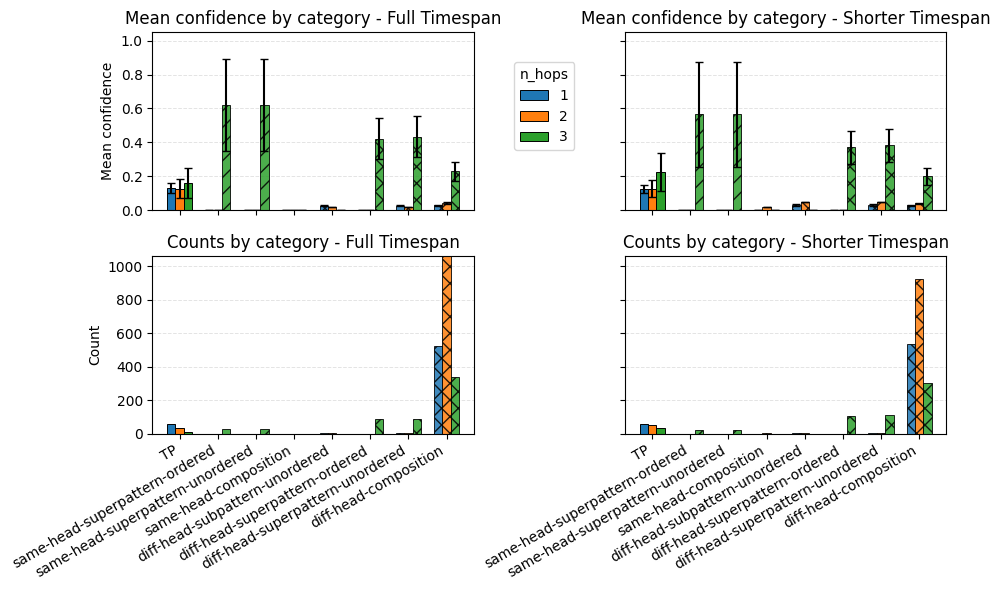

In [119]:
# Pick dataset groups by substring (averaged across runs)
ds_full_med = [d for d in df_all_combined['dataset'].unique()
               if d.startswith('synt_tlogic_like_med')]
ds_shorter_med = [d for d in df_all_combined['dataset'].unique()
                  if d.startswith('data_tlogic_like_shorter_pattern_tmax_med')]

# Sanity
print("Full (med) datasets:", ds_full_med)
print("Shorter (med) datasets:", ds_shorter_med)

# Aggregate for FULL (med)
_, summ_full_med, counts_full_med = build_conf_and_count_tables(
    df_all_combined, df_fp_combined, ds_full_med
)

# Aggregate for SHORTER (med)
_, summ_shorter_med, counts_shorter_med = build_conf_and_count_tables(
    df_all_combined, df_fp_combined, ds_shorter_med
)

# Category order you’ve been using
category_order = [
    'TP',
    # 'same-head-subpattern-ordered',
    # 'same-head-subpattern-unordered',
    'same-head-superpattern-ordered',
    'same-head-superpattern-unordered',
    'same-head-composition',
    # 'diff-head-subpattern-ordered',
    'diff-head-subpattern-unordered',
    'diff-head-superpattern-ordered',
    'diff-head-superpattern-unordered',
    'diff-head-composition',
]

# 2x2 plot
# fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False, sharey=False)

# # Top-left: confidence (full, med)
# plot_conf_panel(
#     axes[0, 0], summ_full_med, category_order,
#     title='Mean confidence by category — Full (Medium Size)'
# )

# # Top-right: confidence (shorter, med)
# plot_conf_panel(
#     axes[0, 1], summ_shorter_med, category_order,
#     title='Mean confidence by category — Shorter (Medium Size)'
# )

# # Bottom-left: counts (full, med)
# plot_count_panel(
#     axes[1, 0], counts_full_med, category_order,
#     title='Counts by category — Full (Medium Size)'
# )

# # Bottom-right: counts (shorter, med)
# plot_count_panel(
#     axes[1, 1], counts_shorter_med, category_order,
#     title='Counts by category — Shorter (Medium Size)'
# )

# # One shared legend for n_hops: put it in the upper-right of the whole figure
# handles, labels = axes[0, 0].get_legend_handles_labels()
# fig.legend(handles, labels, title="n_hops", loc="upper right", bbox_to_anchor=(0.98, 0.98))

# plt.tight_layout(rect=[0, 0, 0.96, 1])  # leave room for the global legend
# plt.show()

# 2x2 plot: share y within each row
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=False, sharey='row')

# Top-left: confidence (full, med)
plot_conf_panel(
    axes[0, 0], summ_full_med, category_order,
    title='Mean confidence by category - Full Timespan'
)

# Top-right: confidence (shorter, med)
plot_conf_panel(
    axes[0, 1], summ_shorter_med, category_order,
    title='Mean confidence by category - Shorter Timespan'
)

# Bottom-left: counts (full, med)
plot_count_panel(
    axes[1, 0], counts_full_med, category_order,
    title='Counts by category - Full Timespan'
)

# Bottom-right: counts (shorter, med)
plot_count_panel(
    axes[1, 1], counts_shorter_med, category_order,
    title='Counts by category - Shorter Timespan'
)

# --- AFTER drawing, adjust axes ---

# 1) Remove x-axis tick labels from the first row
# for ax in axes[0, :]:
#     ax.set_xlabel('')
#     ax.set_xticklabels([])

# # 2) Share y within each row already done via sharey='row'.
# #    Hide the y-axis labels/ticks on the right column
# for ax in axes[:, 1]:
#     ax.set_ylabel('')
#     ax.set_yticklabels([])

# # 3) Add light dashed horizontal gridlines to all facets
# for ax in axes.ravel():
#     ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.35)
#     ax.set_axisbelow(True)  # grid behind bars

# --- layout tweaks AFTER drawing ---

# 1) share y within each row (done at subplot construction)
# fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False, sharey='row')

# 2) Remove x tick labels from the top row
for ax in axes[0, :]:
    ax.set_xlabel('')
    ax.set_xticklabels([])

# 3) Hide ONLY the right column's y tick labels (keep left column visible)
for ax in axes[:, 1]:
    ax.tick_params(axis='y', which='both', labelleft=False)  # hide tick labels
    ax.set_ylabel('')  # remove y-axis title on right

# 4) Ensure left column has y-axis titles (in case panel funcs didn’t set them)
axes[0, 0].set_ylabel('Mean confidence')
axes[1, 0].set_ylabel('Count')

# 5) Light dashed horizontal gridlines everywhere
for ax in axes.ravel():
    ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.35)
    ax.set_axisbelow(True)

# One shared legend for n_hops: put it in the upper-right of the whole figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="n_hops",
           loc="upper right", bbox_to_anchor=(.58, 0.9))

plt.tight_layout(rect=[0, 0, 0.96, 1])  # leave room for the global legend
plt.show()


In [121]:
# ---------- helpers for SUPPORT (mirror of confidence helpers) ----------

def make_tp_fp_support_df(df_all, df_fp_all, datasets, fp_col='taxonomy_labels'):
    """
    Returns tidy: dataset, n_hops, category, support
    TP support = mined_support; FP support = 'support' in df_fp_all.
    """
    rows = []

    # TRUE POSITIVES (retrieved GT patterns with support)
    tp = (df_all[df_all['retrieved'] & df_all['dataset'].isin(datasets)]
            .dropna(subset=['mined_support']))
    rows.append(tp[['dataset','n_hops']].assign(
        category='TP',
        support=tp['mined_support'].astype(float)
    ))

    # FALSE POSITIVES
    if fp_col in df_fp_all.columns and 'support' in df_fp_all.columns:
        fpf = df_fp_all[df_fp_all['dataset'].isin(datasets)].copy()
        fpf = fpf.explode(fp_col)
        fpf = fpf.dropna(subset=[fp_col, 'support'])
        fpf = fpf.rename(columns={fp_col: 'category'})
        rows.append(fpf[['dataset','n_hops','category','support']].assign(
            support=lambda d: d['support'].astype(float)
        ))

    out = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(
        columns=['dataset','n_hops','category','support']
    )
    out['n_hops'] = pd.Categorical(out['n_hops'], [1,2,3], ordered=True)
    return out


def summarize_support(df):
    if df.empty:
        return df
    grp = (df.groupby(['dataset','n_hops','category'], observed=True)
             .agg(mean_supp=('support','mean'),
                  sem=('support','sem'),
                  n=('support','size'))
             .reset_index())
    grp['ci95'] = 1.96 * grp['sem'].fillna(0.0)
    return grp


def plot_support_panel(ax, summ, category_order, title):
    hop_levels = [1,2,3]
    hop_palette = {1:"#1f77b4", 2:"#ff7f0e", 3:"#2ca02c"}

    def hatch_for(cat):
        if cat == "TP": return ""
        return "//" if cat.startswith("same-head") else "xx"

    x_idx = np.arange(len(category_order))
    bar_width = 0.22

    for i, hop in enumerate(hop_levels):
        sub = summ[summ['n_hops'] == hop]
        y, y_ci = [], []
        for cat in category_order:
            rows = sub[sub['category'] == cat]
            if not rows.empty:
                y.append(rows['mean_supp'].mean())
                y_ci.append(rows['ci95'].mean())
            else:
                y.append(np.nan); y_ci.append(0.0)
        y = np.array(y, dtype=float)
        y_ci = np.array(y_ci, dtype=float)
        xpos = x_idx + (i - (len(hop_levels)-1)/2)*bar_width

        bars = ax.bar(
            xpos, np.nan_to_num(y, nan=0.0), width=bar_width,
            color=hop_palette.get(hop, '#888'),
            edgecolor='black', yerr=y_ci, capsize=3, linewidth=0.7,
            label=f'{hop}'
        )
        for rect, cat in zip(bars, category_order):
            rect.set_hatch(hatch_for(cat))
            rect.set_alpha(1.0 if cat == "TP" else 0.85)

    ax.set_xticks(x_idx)
    ax.set_xticklabels(category_order, rotation=30, ha='right')
    ax.set_ylabel('Mean support')
    ax.set_ylim(0, max(1.05, ax.get_ylim()[1]))  # leave headroom
    ax.set_title(title)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.35)
    ax.set_axisbelow(True)


In [147]:
def add_group_separators(ax, breaks, color='0.6', lw=1.0, ls='--', zorder=0):
    """
    Draw vertical separator lines between grouped x-categories.

    Parameters
    ----------
    ax : matplotlib Axes
    breaks : iterable of int
        Category indices AFTER which to draw a separator.
        Lines will be drawn at x = idx + 0.5.
    color, lw, ls, zorder : style for the separator lines.
    """
    ymin, ymax = ax.get_ylim()
    # make sure separators sit behind bars & grids
    for idx in breaks:
        ax.vlines(idx + 0.5, ymin, ymax, colors=color, linestyles=ls, linewidth=lw, zorder=zorder)
    # if y-limits change later (e.g., symlog), refresh them
    ax.set_ylim(ymin, ymax)


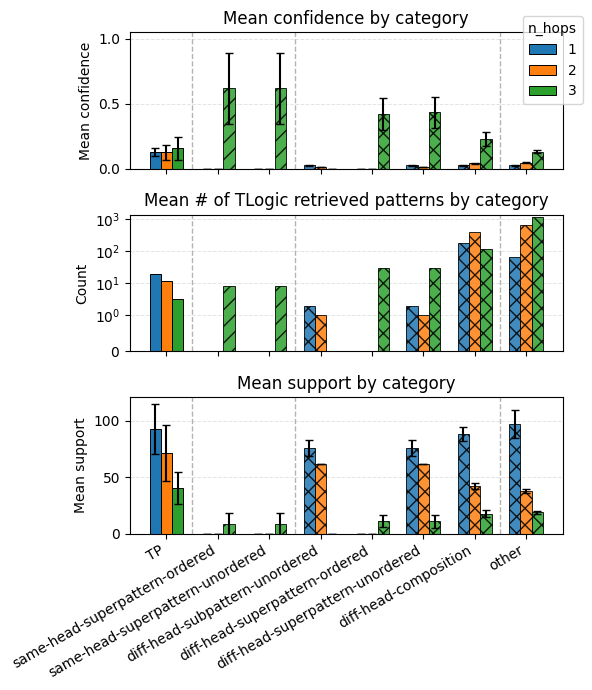

In [148]:
# Pick the FULL (med) group you were using before
ds_full_med = [d for d in df_all_combined['dataset'].unique()
               if d.startswith('synt_tlogic_like_med')]

# 1) confidence summary (you already have these helpers)
conf_df_full, summ_full, counts_full = build_conf_and_count_tables(
    df_all_combined, df_fp_combined, ds_full_med
)

# 2) support summary
supp_df_full = make_tp_fp_support_df(df_all_combined, df_fp_combined, ds_full_med)
summ_supp_full = summarize_support(supp_df_full)

# Category order
category_order = [
    'TP',
    'same-head-superpattern-ordered',
    'same-head-superpattern-unordered',
    'diff-head-subpattern-unordered',
    'diff-head-superpattern-ordered',
    'diff-head-superpattern-unordered',
    'diff-head-composition',
    'other',
]

# --- 3 rows × 1 column (confidence, counts, support) ---
fig, axes = plt.subplots(3, 1, figsize=(6, 7), sharex=True)

# Row 1: confidence
plot_conf_panel(
    axes[0], summ_full, category_order,
    title='Mean confidence by category'
)

# Row 2: counts
plot_count_panel(
    axes[1], counts_full, category_order,
    title='Mean # of TLogic retrieved patterns by category'
)

# Row 3: support (new)
plot_support_panel(
    axes[2], summ_supp_full, category_order,
    title='Mean support by category'
)

# Hide x labels for top/middle; keep them ONLY on the bottom row
for ax in axes[:-1]:
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelbottom=False)   # hide tick labels

# Re-apply x tick labels on the bottom row explicitly
xpos = np.arange(len(category_order))
axes[-1].set_xticks(xpos)
axes[-1].set_xticklabels(category_order, rotation=30, ha='right')
axes[-1].tick_params(axis='x', labelbottom=True)  # ensure they show

# Light dashed grid already added in panels; ensure consistency
for ax in axes:
    ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.35)
    ax.set_axisbelow(True)

axes[1].set_yscale('symlog', linthresh=1)

# Single legend for n_hops (reuse handles from first axis)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='n_hops', loc='upper right', bbox_to_anchor=(0.98, 0.98))

group_breaks = [0, 2, 6]

# Add vertical separators to each subplot
for ax in axes:
    add_group_separators(ax, group_breaks, color='0.7', lw=1.0, ls='--')

plt.tight_layout(rect=[0, 0, 0.96, 1])
plt.show()
